# Day 08 - Handling Class Imbalance with SMOTE

Our dataset has a big problem:
- 93% of people did NOT default
- Only 7% defaulted

When a model trains on this, it sees mostly 0s.
It learns to just say 0 for everything because that is usually correct.
It never really learns what a defaulter looks like.

SMOTE fixes this by creating SYNTHETIC (fake but realistic) examples of the minority class.
It looks at existing defaulters and creates new similar ones.
After SMOTE, the model sees equal amounts of both classes.

VERY IMPORTANT RULE:
SMOTE only goes on TRAINING data.
NEVER apply SMOTE to test data.
The test data must stay real.

## Step 1 - Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sklearn
import imblearn

print("sklearn:", sklearn.__version__)
print("imblearn:", imblearn.__version__)

sklearn: 1.7.2
imblearn: 0.14.0


In [3]:
# Install if needed: pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

## Step 2 - Load data

In [4]:
df = pd.read_csv('cs-training-day7-features.csv', index_col=0)
print('Shape:', df.shape)

Shape: (149999, 16)


In [5]:
# Check class balance first
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139973
1     10026
Name: count, dtype: int64

In [6]:
df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

SeriousDlqin2yrs
0    93.315955
1     6.684045
Name: proportion, dtype: float64

## Step 3 - Split into X and y

In [7]:
X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

In [8]:
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (149999, 15)
y shape: (149999,)


## Step 4 - Fill any remaining missing values

SMOTE does not work if there are missing values.
Let us check and fill any that remain.

In [9]:
print('Missing values in X:')
print(X.isnull().sum())

Missing values in X:
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
income_is_missing                       0
debt_to_income                          0
total_late_payments                     0
ever_late                               0
income_per_dependent                    0
dtype: int64


## Step 5 - Apply SMOTE

In [11]:
print('Before SMOTE:')
print('Class 0 (no default):', (y == 0).sum())
print('Class 1 (default):', (y == 1).sum())

Before SMOTE:
Class 0 (no default): 139973
Class 1 (default): 10026


In [12]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [13]:
print('After SMOTE:')
print('Class 0 (no default):', (y_resampled == 0).sum())
print('Class 1 (default):', (y_resampled == 1).sum())

After SMOTE:
Class 0 (no default): 139973
Class 1 (default): 139973


In [14]:
print('Total rows before SMOTE:', len(X))
print('Total rows after SMOTE:', len(X_resampled))
print('New rows created by SMOTE:', len(X_resampled) - len(X))

Total rows before SMOTE: 149999
Total rows after SMOTE: 279946
New rows created by SMOTE: 129947


## Step 6 - Visualize the difference

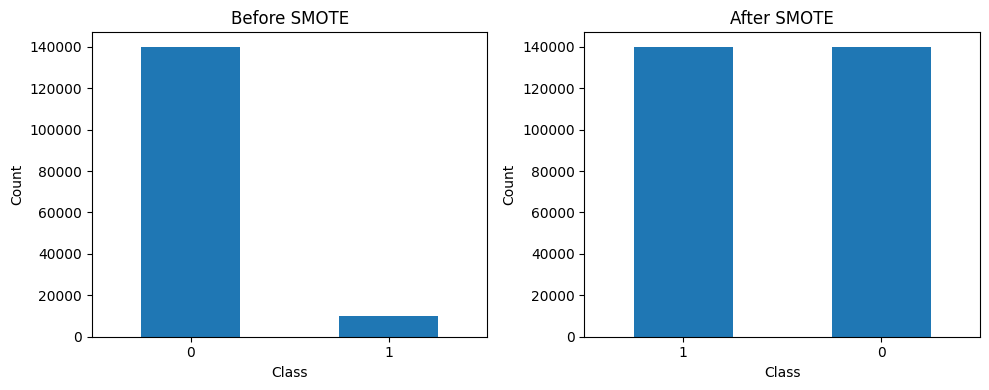

In [15]:
# Before
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar')
plt.title('Before SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
pd.Series(y_resampled).value_counts().plot(kind='bar')
plt.title('After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Step 7 - Check that SMOTE data looks realistic

SMOTE creates fake data. Let us make sure it looks similar to the original.

In [16]:
X_resampled_df = pd.DataFrame(X_resampled, columns=X.columns)

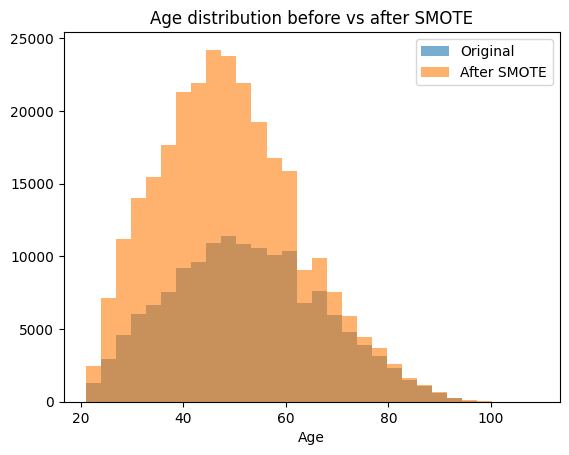

In [27]:
# Compare age distribution before and after
plt.hist(X['age'], bins=30, alpha=0.6, label='Original')
plt.hist(X_resampled_df['age'], bins=30, alpha=0.6, label='After SMOTE')
plt.title('Age distribution before vs after SMOTE')
plt.xlabel('Age')
plt.legend()
plt.show()

In [28]:
# Basic stats comparison
print('Age stats BEFORE SMOTE:')
print(X['age'].describe())
print()
print('Age stats AFTER SMOTE:')
print(X_resampled_df['age'].describe())

Age stats BEFORE SMOTE:
count    149999.000000
mean         52.295555
std          14.771298
min          21.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

Age stats AFTER SMOTE:
count    279946.000000
mean         48.992702
std          13.856557
min          21.000000
25%          39.000000
50%          48.000000
75%          58.000000
max         109.000000
Name: age, dtype: float64


## Step 8 - Save the resampled data

In [23]:
X_resampled_df['SeriousDlqin2yrs'] = y_resampled
X_resampled_df.to_csv('cs-training-day8-smote.csv', index=False)
print('Saved!')
print('Final shape:', X_resampled_df.shape)

Saved!
Final shape: (279946, 16)


## My observations today (fill this yourself)

1. How many new rows did SMOTE create : 1,29,947
2. Why should we NEVER apply SMOTE to test data : SMOTE is only for helping the model learn during training,
not for evaluating the model.
3. Does the age distribution look similar before and after SMOTE : Yes ! both have picks around 45-55 , range remain roughly 20-100 years
4. What is the risk of overusing SMOTE (think about it) Minority class becomes filled with artificial points.

---
Tomorrow - Day 09: Encoding and scaling properly

In [26]:
new_rows = len(X_resampled_df) - len(X)
new_rows

129947